# Datathon 2026 — Part 2 Final EDA Dashboard

Notebook này là bản **dashboard final** để gom lại các biểu đồ quan trọng từ `part2.ipynb`, chia theo từng mặt phân tích kinh doanh, và bổ sung thêm các chart về **mùa vụ / seasonality**.

Mục tiêu của dashboard:

1. **Descriptive** — Doanh nghiệp đang xảy ra điều gì?
2. **Diagnostic** — Vì sao điều đó xảy ra?
3. **Predictive** — Nếu xu hướng tiếp tục, rủi ro/cơ hội tiếp theo là gì?
4. **Prescriptive** — Doanh nghiệp nên hành động gì?

Cấu trúc dashboard:

1. Revenue & Seasonality
2. Customer & Retention
3. Product Portfolio & Profitability
4. Promotion Effectiveness
5. Returns & Customer Experience
6. Inventory & Operations
7. Web Traffic & Marketing Efficiency
8. Prescriptive Action Playbook

In [1]:
# 0. Setup
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (13, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 11

# Robust data path detection.
# This works if the notebook is placed either in repo root or in a notebooks/ folder.
candidate_dirs = [
    Path("datathon-2026-round-1"),
    Path("../datathon-2026-round-1"),
    Path("."),
    Path(".."),
]

required_file = "orders.csv"
DATA_DIR = None
for d in candidate_dirs:
    if (d / required_file).exists():
        DATA_DIR = d
        break

if DATA_DIR is None:
    raise FileNotFoundError(
        "Cannot find CSV data folder. Put this notebook in repo root or notebooks/, "
        "and make sure datathon-2026-round-1/ exists."
    )

PROJECT_ROOT = DATA_DIR.parent if DATA_DIR.name == "datathon-2026-round-1" else Path(".")
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("FIG_DIR:", FIG_DIR.resolve())

DATA_DIR: F:\THANHTUNG\HOC_KI_6\DS\Datathon\datathon-2026-round-1
FIG_DIR: F:\THANHTUNG\HOC_KI_6\DS\Datathon\outputs\figures


In [2]:
# 1. Load data
customers = pd.read_csv(DATA_DIR / "customers.csv")
geography = pd.read_csv(DATA_DIR / "geography.csv")
inventory = pd.read_csv(DATA_DIR / "inventory.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
orders = pd.read_csv(DATA_DIR / "orders.csv")
payments = pd.read_csv(DATA_DIR / "payments.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
promotions = pd.read_csv(DATA_DIR / "promotions.csv")
returns = pd.read_csv(DATA_DIR / "returns.csv")
reviews = pd.read_csv(DATA_DIR / "reviews.csv")
sales = pd.read_csv(DATA_DIR / "sales.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")
shipments = pd.read_csv(DATA_DIR / "shipments.csv")
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv")

# Parse date columns
date_map = {
    "orders": (orders, ["order_date"]),
    "customers": (customers, ["signup_date"]),
    "returns": (returns, ["return_date"]),
    "reviews": (reviews, ["review_date"]),
    "shipments": (shipments, ["ship_date", "delivery_date"]),
    "promotions": (promotions, ["start_date", "end_date"]),
    "sales": (sales, ["Date"]),
    "sample_submission": (sample_submission, ["Date"]),
    "inventory": (inventory, ["snapshot_date"]),
    "web_traffic": (web_traffic, ["date"]),
}

for _, (df, cols) in date_map.items():
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

print("Loaded tables:")
for name, df in {
    "customers": customers, "geography": geography, "inventory": inventory,
    "order_items": order_items, "orders": orders, "payments": payments,
    "products": products, "promotions": promotions, "returns": returns,
    "reviews": reviews, "sales": sales, "shipments": shipments,
    "web_traffic": web_traffic,
}.items():
    print(f"{name:15s}: {df.shape}")

Loaded tables:
customers      : (121930, 7)
geography      : (39948, 4)
inventory      : (60247, 17)
order_items    : (714669, 7)
orders         : (646945, 8)
payments       : (646945, 4)
products       : (2412, 8)
promotions     : (50, 10)
returns        : (39939, 7)
reviews        : (113551, 7)
sales          : (3833, 3)
shipments      : (566067, 4)
web_traffic    : (3652, 7)


In [3]:
# 2. Helper functions

def save_fig(name: str):
    """Save current matplotlib figure to outputs/figures."""
    path = FIG_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved figure: {path}")


def pct(x):
    return f"{x:.2%}"

## 0. Master Analytical Table

Mục đích: tạo một bảng phân tích chính `line_items`, nối `order_items` với orders, customers, products, returns, reviews, promotions và shipments. Bảng này giúp các chart phía sau dùng cùng một logic doanh thu/lợi nhuận.

In [4]:
# Payment, shipment, return, review aggregates
payments_order = payments.groupby("order_id", as_index=False).agg(
    payment_value=("payment_value", "sum"),
    installments=("installments", "max"),
)

shipments_order = shipments.copy()
shipments_order["delivery_days"] = (shipments_order["delivery_date"] - shipments_order["ship_date"]).dt.days
shipments_order = shipments_order.groupby("order_id", as_index=False).agg(
    ship_date=("ship_date", "min"),
    delivery_date=("delivery_date", "max"),
    shipping_fee=("shipping_fee", "sum"),
    delivery_days=("delivery_days", "mean"),
)

returns_item = returns.groupby(["order_id", "product_id"], as_index=False).agg(
    return_records=("return_id", "count"),
    return_quantity=("return_quantity", "sum"),
    refund_amount=("refund_amount", "sum"),
)

reviews_item = reviews.groupby(["order_id", "product_id"], as_index=False).agg(
    avg_rating=("rating", "mean"),
    review_count=("review_id", "count"),
)

customer_geo = customers.merge(
    geography[["zip", "region", "district"]].drop_duplicates("zip"),
    on="zip",
    how="left",
)

orders_master = (
    orders
    .merge(customer_geo[["customer_id", "gender", "age_group", "acquisition_channel", "region", "district", "signup_date"]], on="customer_id", how="left")
    .merge(payments_order, on="order_id", how="left")
    .merge(shipments_order, on="order_id", how="left")
)

line_items = (
    order_items
    .merge(orders_master, on="order_id", how="left")
    .merge(products, on="product_id", how="left")
    .merge(returns_item, on=["order_id", "product_id"], how="left")
    .merge(reviews_item, on=["order_id", "product_id"], how="left")
    .merge(promotions[["promo_id", "promo_type", "promo_channel", "stackable_flag", "discount_value"]], on="promo_id", how="left")
)

line_items["gross_revenue"] = line_items["quantity"] * line_items["unit_price"]
line_items["net_revenue"] = line_items["gross_revenue"] - line_items["discount_amount"].fillna(0)
line_items["line_cogs"] = line_items["quantity"] * line_items["cogs"]
line_items["gross_profit"] = line_items["net_revenue"] - line_items["line_cogs"]
line_items["gross_margin"] = line_items["gross_profit"] / line_items["net_revenue"].replace(0, np.nan)
line_items["is_returned"] = line_items["return_records"].fillna(0).gt(0)
line_items["order_month"] = line_items["order_date"].dt.to_period("M").dt.to_timestamp()
line_items["order_year"] = line_items["order_date"].dt.year
line_items["promo_applied"] = line_items["promo_id"].notna()
line_items["discount_pct"] = (line_items["discount_amount"].fillna(0) / line_items["gross_revenue"].replace(0, np.nan)).clip(0, 1)

print("line_items shape:", line_items.shape)
line_items[["order_id", "product_id", "order_date", "category", "segment", "net_revenue", "gross_profit", "is_returned"]].head()

line_items shape: (714669, 52)


,order_id,product_id,order_date,category,segment,net_revenue,gross_profit,is_returned
0,1,2400,2012-07-04,GenZ,Trendy,7967.54,590.953941,False
1,2,609,2012-07-04,Streetwear,Everyday,71163.75,8249.820384,True
2,3,396,2012-07-04,Streetwear,Balanced,33660.99,3387.953233,False
3,4,635,2012-07-04,Streetwear,Everyday,53196.25,7169.097610,False
4,6,1935,2012-07-06,Outdoor,Activewear,1597.84,549.143643,False


# 1. Revenue & Seasonality

**Câu hỏi kinh doanh:** Doanh thu và lợi nhuận thay đổi như thế nào theo thời gian? Có mùa vụ theo tháng/ngày trong tuần không?

Đây là phần Descriptive nền tảng, đồng thời hỗ trợ Predictive vì seasonal pattern có thể dùng để lập kế hoạch tồn kho, logistics và campaign.

In [5]:
# KPI overview
kpi = pd.DataFrame({
    "KPI": [
        "Total Orders", "Total Customers", "Net Revenue", "Gross Profit",
        "Gross Margin", "Line Return Rate", "Order Cancel Rate", "Avg Review Rating"
    ],
    "Value": [
        f"{orders['order_id'].nunique():,.0f}",
        f"{customers['customer_id'].nunique():,.0f}",
        f"{line_items['net_revenue'].sum():,.0f}",
        f"{line_items['gross_profit'].sum():,.0f}",
        pct(line_items['gross_profit'].sum() / line_items['net_revenue'].sum()),
        pct(line_items['is_returned'].mean()),
        pct((orders['order_status'] == 'cancelled').mean()),
        f"{reviews['rating'].mean():.2f}",
    ]
})
kpi

,KPI,Value
0,Total Orders,"646,945"
1,Total Customers,"121,930"
2,Net Revenue,"15,680,869,265"
3,Gross Profit,"1,517,418,746"
4,Gross Margin,9.68%
5,Line Return Rate,5.59%
6,Order Cancel Rate,9.19%
7,Avg Review Rating,3.94


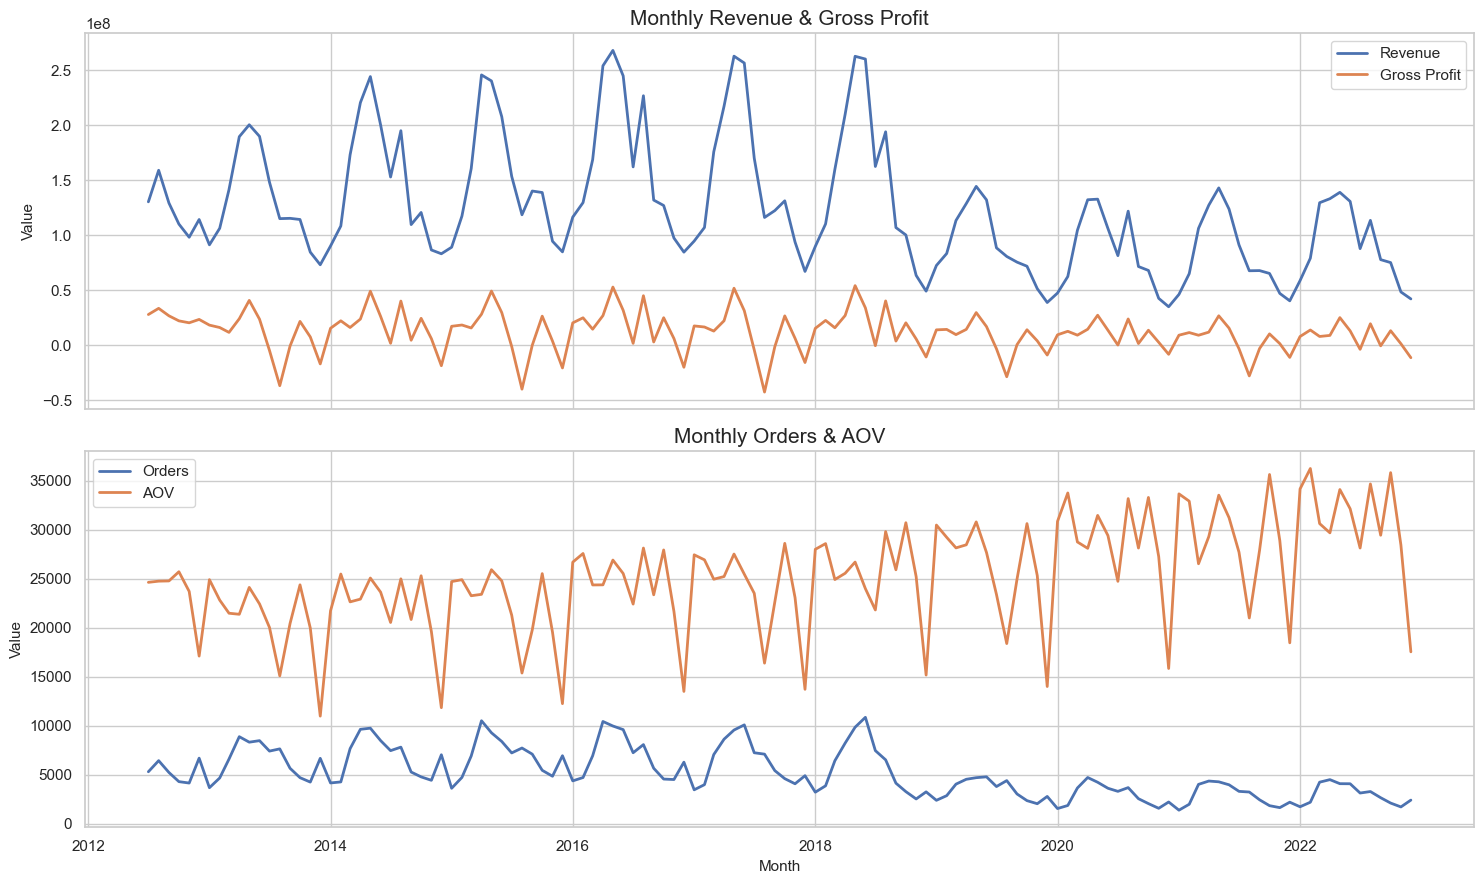

Saved figure: outputs\figures\fig1_revenue_profit_trend.png


,order_month,revenue,gross_profit,orders,aov,gross_margin
121,2022-08-01,1.135360e+08,1.950263e+07,3274,34678.071750,0.171775
122,2022-09-01,7.781686e+07,-5.783857e+05,2643,29442.624499,-0.007433
123,2022-10-01,7.513702e+07,1.316713e+07,2097,35830.719638,0.175242
124,2022-11-01,4.842012e+07,1.322094e+06,1703,28432.246418,0.027305
125,2022-12-01,4.208916e+07,-1.140051e+07,2400,17537.149921,-0.270866


In [6]:
# Chart 1A — Monthly revenue and gross profit trend
monthly = line_items.groupby("order_month", as_index=False).agg(
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    orders=("order_id", "nunique"),
)
monthly["aov"] = monthly["revenue"] / monthly["orders"]
monthly["gross_margin"] = monthly["gross_profit"] / monthly["revenue"]

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)
axes[0].plot(monthly["order_month"], monthly["revenue"], label="Revenue", linewidth=2)
axes[0].plot(monthly["order_month"], monthly["gross_profit"], label="Gross Profit", linewidth=2)
axes[0].set_title("Monthly Revenue & Gross Profit")
axes[0].set_ylabel("Value")
axes[0].legend()

axes[1].plot(monthly["order_month"], monthly["orders"], label="Orders", linewidth=2)
axes[1].plot(monthly["order_month"], monthly["aov"], label="AOV", linewidth=2)
axes[1].set_title("Monthly Orders & AOV")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Value")
axes[1].legend()

save_fig("fig1_revenue_profit_trend.png")
monthly.tail()

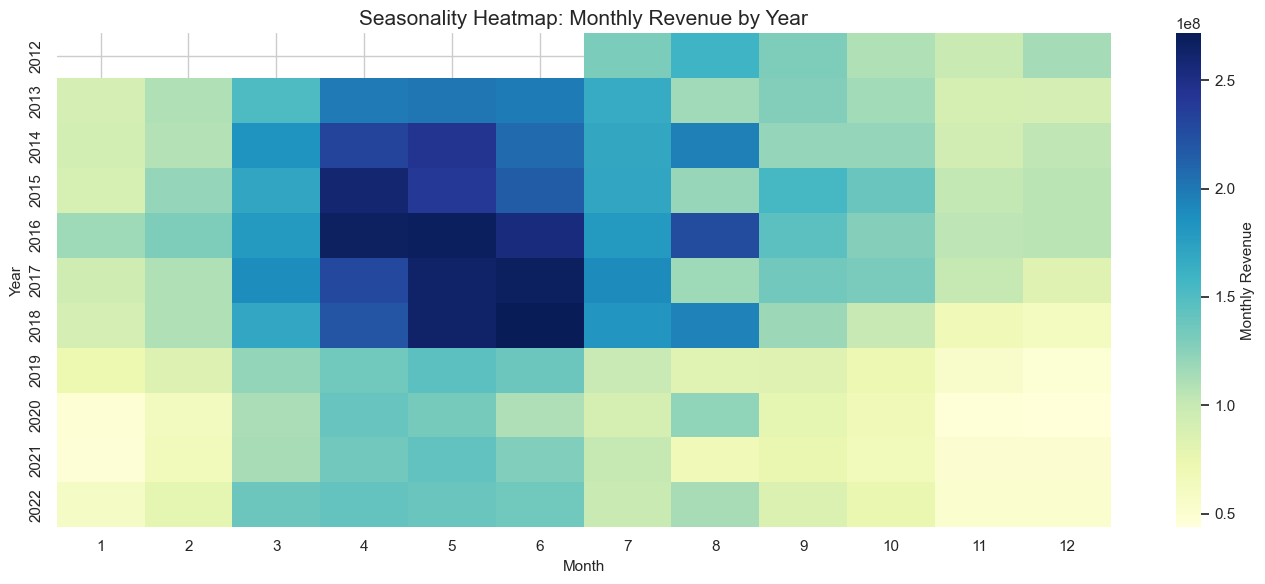

Saved figure: outputs\figures\fig2_revenue_seasonality_month_heatmap.png


In [7]:
# Chart 1B — Seasonality heatmap by year and month
sales_season = sales.copy()
sales_season["year"] = sales_season["Date"].dt.year
sales_season["month"] = sales_season["Date"].dt.month
monthly_sales = sales_season.groupby(["year", "month"], as_index=False).agg(revenue=("Revenue", "sum"))
heat = monthly_sales.pivot(index="year", columns="month", values="revenue")

plt.figure(figsize=(14, 6))
sns.heatmap(heat, cmap="YlGnBu", cbar_kws={"label": "Monthly Revenue"})
plt.title("Seasonality Heatmap: Monthly Revenue by Year")
plt.xlabel("Month")
plt.ylabel("Year")
save_fig("fig2_revenue_seasonality_month_heatmap.png")

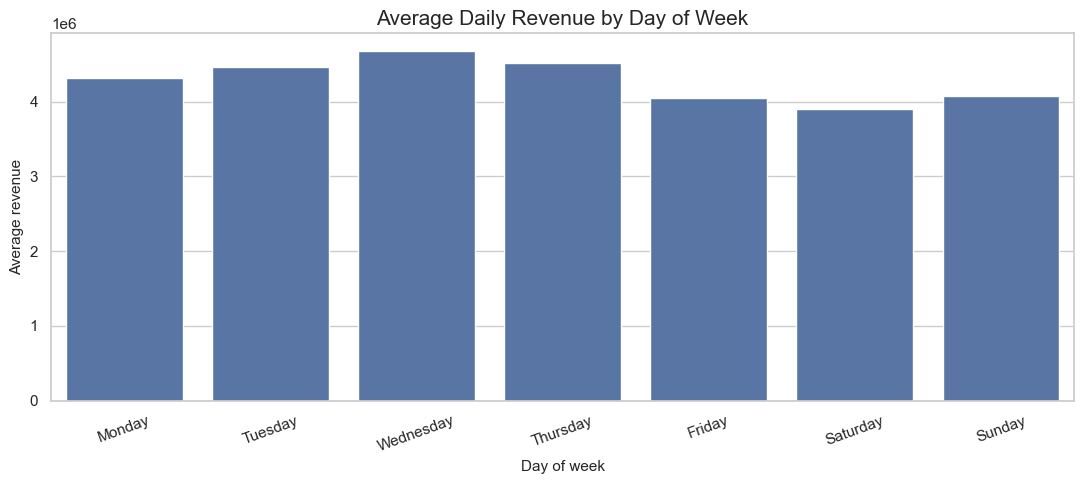

Saved figure: outputs\figures\fig3_day_of_week_seasonality.png


,day_of_week,avg_revenue
1,Monday,4.311035e+06
5,Tuesday,4.465103e+06
6,Wednesday,4.680065e+06
4,Thursday,4.523044e+06
0,Friday,4.046390e+06
2,Saturday,3.906581e+06
3,Sunday,4.073854e+06


In [8]:
# Chart 1C — Day-of-week seasonality
sales_dow = sales.copy()
sales_dow["day_of_week"] = sales_dow["Date"].dt.day_name()
sales_dow["month"] = sales_dow["Date"].dt.month

order_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_summary = sales_dow.groupby("day_of_week", as_index=False).agg(avg_revenue=("Revenue", "mean"))
dow_summary["day_of_week"] = pd.Categorical(dow_summary["day_of_week"], categories=order_days, ordered=True)
dow_summary = dow_summary.sort_values("day_of_week")

plt.figure(figsize=(11, 5))
sns.barplot(data=dow_summary, x="day_of_week", y="avg_revenue", color="#4C72B0")
plt.title("Average Daily Revenue by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Average revenue")
plt.xticks(rotation=20)
save_fig("fig3_day_of_week_seasonality.png")
dow_summary

### Insight — Doanh thu và tính mùa vụ

**Phát hiện chính:** Doanh thu không phân bổ đều theo thời gian mà có dấu hiệu mùa vụ theo tháng và theo ngày trong tuần. Một số giai đoạn có doanh thu cao hơn rõ rệt, cho thấy nhu cầu của khách hàng có tính chu kỳ thay vì ổn định hoàn toàn qua thời gian.

**Ý nghĩa kinh doanh:** Nếu doanh nghiệp chỉ phản ứng sau khi nhu cầu tăng, rủi ro thiếu hàng, quá tải vận hành và giao hàng chậm sẽ cao hơn. Ngược lại, nếu nhận diện được các tháng hoặc ngày có nhu cầu cao từ dữ liệu lịch sử, doanh nghiệp có thể chuẩn bị trước tồn kho, nhân sự kho vận, ngân sách marketing và lịch khuyến mãi.

**Đề xuất hành động:** Doanh nghiệp nên dùng pattern mùa vụ trong quá khứ để lập kế hoạch trước cho inventory, logistics và campaign calendar. Các chiến dịch flash sale, email marketing hoặc push notification nên được ưu tiên vào những ngày/tuần có xu hướng doanh thu cao, trong khi các giai đoạn thấp điểm có thể dùng để chạy chiến dịch kích cầu hoặc xả hàng tồn.

# 2. Customer & Retention

**Câu hỏi kinh doanh:** Tăng trưởng đến từ khách mới hay khách quay lại? Kênh acquisition nào đem lại khách chất lượng hơn?

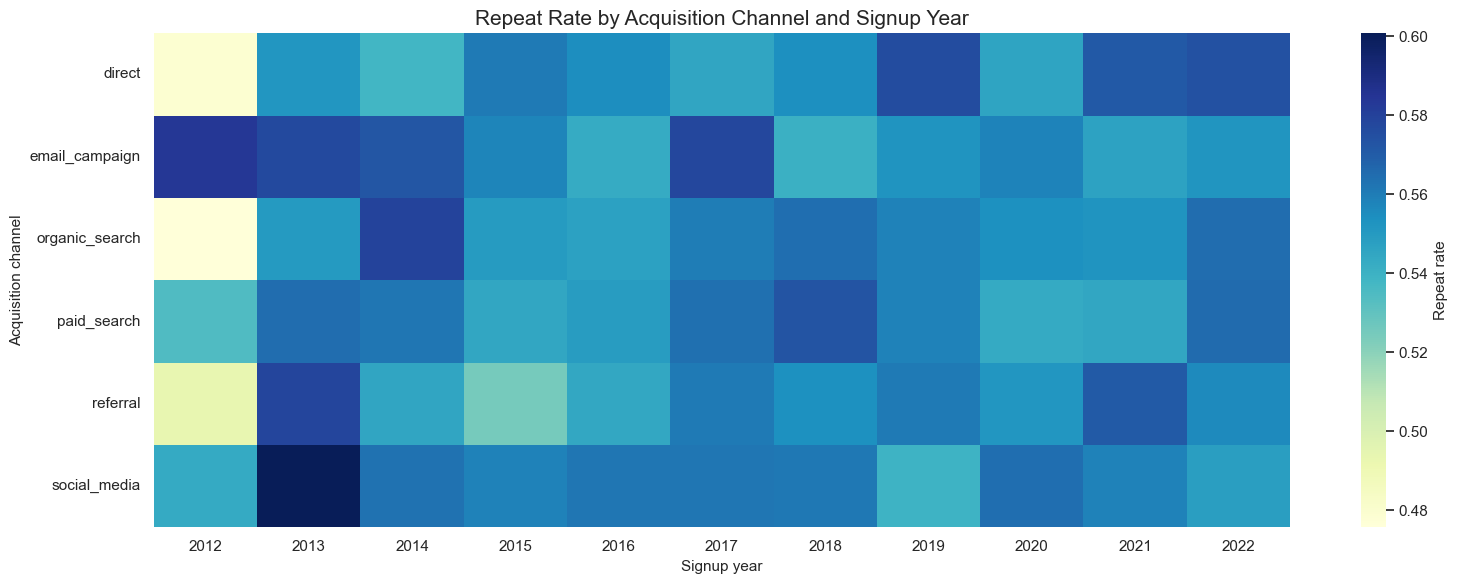

Saved figure: outputs\figures\fig4_repeat_rate_cohort_heatmap.png


,signup_year,acquisition_channel,customers,avg_orders,repeat_rate
11,2013,social_media,591,5.759729,0.600677
9,2013,paid_search,586,5.653584,0.564846
12,2014,direct,394,5.616751,0.538071
14,2014,organic_search,1532,5.577023,0.579634
10,2013,referral,306,5.562092,0.578431
49,2020,email_campaign,2086,5.539789,0.558006
17,2014,social_media,985,5.537056,0.563452
36,2018,direct,1043,5.523490,0.554171
3,2012,paid_search,189,5.492063,0.534392
44,2019,organic_search,4452,5.458446,0.558401


In [9]:
# Chart 2A — Repeat rate by acquisition channel and signup year
cust_orders = orders.groupby("customer_id", as_index=False).agg(
    total_orders=("order_id", "nunique"),
    first_order=("order_date", "min"),
    last_order=("order_date", "max"),
)

cohort = customers[["customer_id", "signup_date", "acquisition_channel", "age_group"]].merge(cust_orders, on="customer_id", how="left")
cohort["total_orders"] = cohort["total_orders"].fillna(0)
cohort["is_repeat"] = cohort["total_orders"] > 1
cohort["signup_year"] = cohort["signup_date"].dt.year

cohort_summary = cohort.groupby(["signup_year", "acquisition_channel"], as_index=False).agg(
    customers=("customer_id", "nunique"),
    avg_orders=("total_orders", "mean"),
    repeat_rate=("is_repeat", "mean"),
)

pivot_repeat = cohort_summary.pivot(index="acquisition_channel", columns="signup_year", values="repeat_rate")

plt.figure(figsize=(16, 6))
sns.heatmap(pivot_repeat, cmap="YlGnBu", cbar_kws={"label": "Repeat rate"})
plt.title("Repeat Rate by Acquisition Channel and Signup Year")
plt.xlabel("Signup year")
plt.ylabel("Acquisition channel")
save_fig("fig4_repeat_rate_cohort_heatmap.png")
cohort_summary.sort_values("avg_orders", ascending=False).head(10)

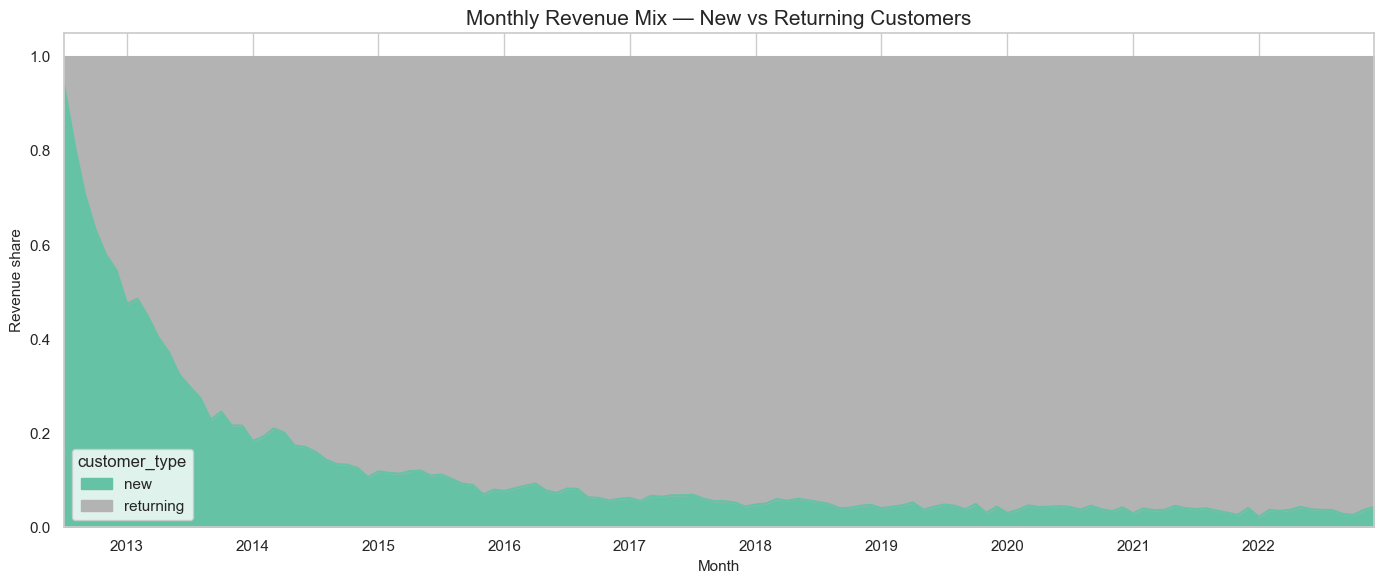

Saved figure: outputs\figures\fig5_new_vs_returning_revenue_mix.png


customer_type,new,returning
order_month,,
2022-01-01,0.022122,0.977878
2022-02-01,0.037016,0.962984
2022-03-01,0.034402,0.965598
2022-04-01,0.037228,0.962772
2022-05-01,0.043420,0.956580
2022-06-01,0.038361,0.961639
2022-07-01,0.037092,0.962908
2022-08-01,0.036723,0.963277
2022-09-01,0.028544,0.971456


In [10]:
# Chart 2B — Monthly revenue mix: new vs returning customers
first_order_date = orders.groupby("customer_id", as_index=False)["order_date"].min().rename(columns={"order_date": "first_order_date"})
ord_type = orders[["order_id", "customer_id", "order_date"]].merge(first_order_date, on="customer_id", how="left")
ord_type["customer_type"] = np.where(ord_type["order_date"] == ord_type["first_order_date"], "new", "returning")

mix = line_items[["order_id", "order_month", "net_revenue"]].merge(ord_type[["order_id", "customer_type"]], on="order_id", how="left")
mix_m = mix.groupby(["order_month", "customer_type"], as_index=False)["net_revenue"].sum()
pivot_mix = mix_m.pivot(index="order_month", columns="customer_type", values="net_revenue").fillna(0)
pivot_share = pivot_mix.div(pivot_mix.sum(axis=1), axis=0)

pivot_share.plot(kind="area", stacked=True, figsize=(14, 6), colormap="Set2")
plt.title("Monthly Revenue Mix — New vs Returning Customers")
plt.xlabel("Month")
plt.ylabel("Revenue share")
save_fig("fig5_new_vs_returning_revenue_mix.png")
pivot_share.tail(12)

### Insight — Khách hàng quay lại và khả năng giữ chân khách hàng

**Phát hiện chính:** Doanh thu không chỉ phụ thuộc vào việc thu hút khách hàng mới, mà còn phụ thuộc rất lớn vào nhóm khách hàng quay lại. Khi tỷ trọng doanh thu từ khách hàng returning suy giảm, vấn đề không còn nằm riêng ở acquisition, mà phản ánh rủi ro trong khả năng giữ chân khách hàng và duy trì tần suất mua lại.

**Ý nghĩa kinh doanh:** Nếu doanh nghiệp chỉ tiếp tục tăng ngân sách kéo traffic hoặc thu hút khách hàng mới mà không cải thiện retention, chi phí tăng trưởng sẽ ngày càng cao. Trong thương mại điện tử thời trang, khách hàng quay lại thường có giá trị dài hạn tốt hơn vì họ đã có niềm tin với thương hiệu, hiểu sản phẩm và có khả năng mua lặp lại.

**Đề xuất hành động:** Doanh nghiệp nên ưu tiên các chương trình CRM, loyalty program, win-back campaign, email remarketing và gợi ý sản phẩm cá nhân hóa cho khách hàng đã từng mua. Hiệu quả acquisition nên được đánh giá không chỉ bằng số lượng khách mới, mà còn bằng tỷ lệ quay lại mua hàng và doanh thu tạo ra trong các lần mua sau.

# 3. Product Portfolio & Profitability

**Câu hỏi kinh doanh:** Doanh thu đang phụ thuộc vào nhóm sản phẩm nào? Nhóm nào có doanh thu cao nhưng margin/return risk xấu?

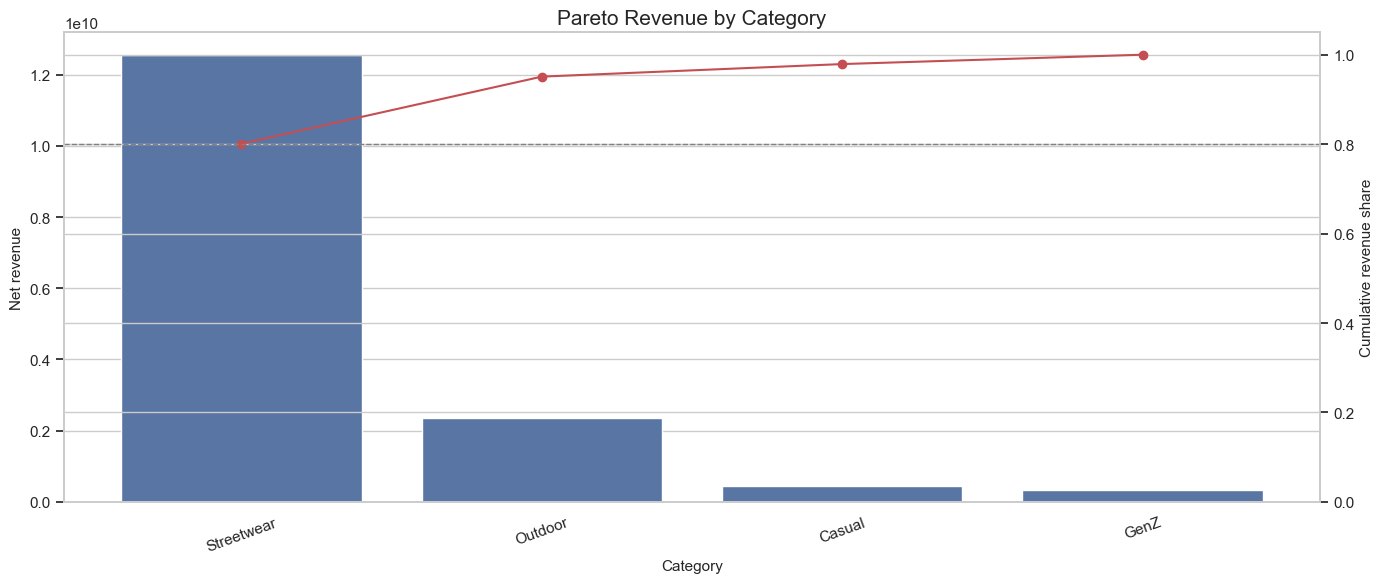

Saved figure: outputs\figures\fig6_category_revenue_pareto.png


,category,revenue,cum_share
3,Streetwear,1.255848e+10,0.800879
2,Outdoor,2.353397e+09,0.950960
0,Casual,4.402852e+08,0.979038
1,GenZ,3.287102e+08,1.000000


In [11]:
# Chart 3A — Pareto revenue by category
cat_rev = line_items.groupby("category", as_index=False).agg(revenue=("net_revenue", "sum")).sort_values("revenue", ascending=False)
cat_rev["cum_share"] = cat_rev["revenue"].cumsum() / cat_rev["revenue"].sum()

fig, ax1 = plt.subplots(figsize=(14, 6))
sns.barplot(data=cat_rev, x="category", y="revenue", ax=ax1, color="#4C72B0")
ax1.set_title("Pareto Revenue by Category")
ax1.set_xlabel("Category")
ax1.set_ylabel("Net revenue")
ax1.tick_params(axis="x", rotation=20)

ax2 = ax1.twinx()
ax2.plot(range(len(cat_rev)), cat_rev["cum_share"], color="#C44E52", marker="o")
ax2.axhline(0.8, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("Cumulative revenue share")
ax2.set_ylim(0, 1.05)

save_fig("fig6_category_revenue_pareto.png")
cat_rev

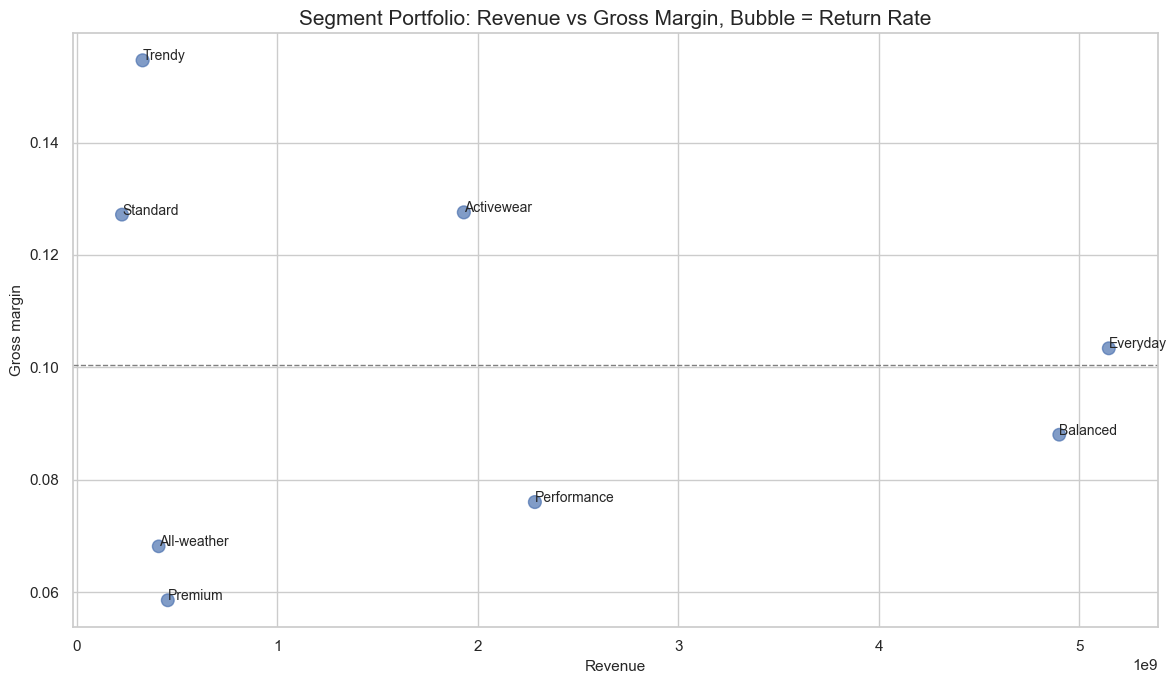

Saved figure: outputs\figures\fig7_segment_portfolio_map.png


,segment,revenue,gross_profit,return_rate,gross_margin
3,Everyday,5.147455e+09,5.321748e+08,0.055568,0.103386
2,Balanced,4.900318e+09,4.312361e+08,0.054320,0.088002
4,Performance,2.285029e+09,1.736938e+08,0.056260,0.076014
0,Activewear,1.930705e+09,2.463395e+08,0.056799,0.127590
5,Premium,4.542119e+08,2.658623e+07,0.055491,0.058533
1,All-weather,4.087651e+08,2.784908e+07,0.053478,0.068130
7,Trendy,3.287102e+08,5.083638e+07,0.057214,0.154654
6,Standard,2.256749e+08,2.870285e+07,0.054951,0.127187


In [12]:
# Chart 3B — Segment portfolio map: revenue vs gross margin, bubble = return rate
seg_perf = line_items.groupby("segment", as_index=False).agg(
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    return_rate=("is_returned", "mean")
)
seg_perf["gross_margin"] = seg_perf["gross_profit"] / seg_perf["revenue"]

plt.figure(figsize=(12, 7))
plt.scatter(seg_perf["revenue"], seg_perf["gross_margin"], s=1500 * seg_perf["return_rate"], alpha=0.7)
for _, r in seg_perf.iterrows():
    plt.annotate(r["segment"], (r["revenue"], r["gross_margin"]), fontsize=10)

plt.title("Segment Portfolio: Revenue vs Gross Margin, Bubble = Return Rate")
plt.xlabel("Revenue")
plt.ylabel("Gross margin")
plt.axhline(seg_perf["gross_margin"].mean(), color="gray", linestyle="--", linewidth=1)
save_fig("fig7_segment_portfolio_map.png")
seg_perf.sort_values("revenue", ascending=False)

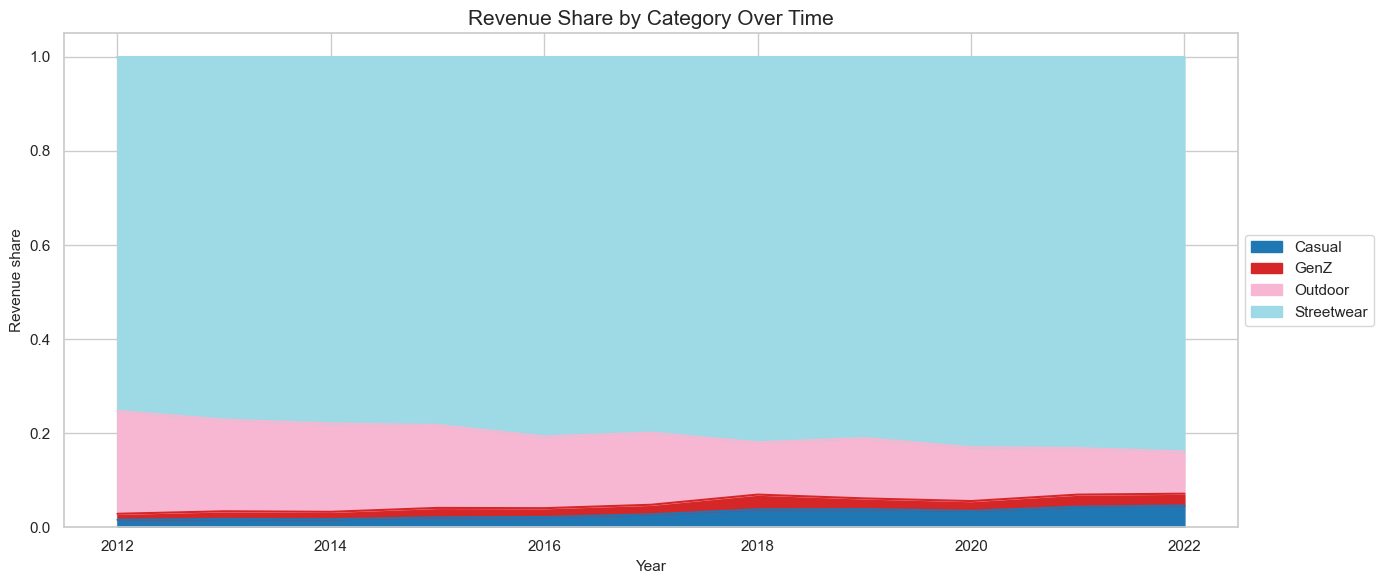

Saved figure: outputs\figures\fig8_category_revenue_share_over_time.png


category,Casual,GenZ,Outdoor,Streetwear
order_year,,,,
2018,0.038114,0.031322,0.111365,0.819199
2019,0.038539,0.022775,0.128311,0.810374
2020,0.034830,0.020844,0.114326,0.830000
2021,0.043767,0.025622,0.099053,0.831558
2022,0.046213,0.025192,0.089561,0.839035


In [13]:
# Chart 3C — Revenue share by category over years
cat_year = line_items.groupby(["order_year", "category"], as_index=False).agg(revenue=("net_revenue", "sum"))
cat_year_pivot = cat_year.pivot(index="order_year", columns="category", values="revenue").fillna(0)
cat_year_share = cat_year_pivot.div(cat_year_pivot.sum(axis=1), axis=0)

cat_year_share.plot(kind="area", stacked=True, figsize=(14, 6), colormap="tab20")
plt.title("Revenue Share by Category Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue share")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
save_fig("fig8_category_revenue_share_over_time.png")
cat_year_share.tail()

### Insight — Danh mục sản phẩm và rủi ro phụ thuộc doanh thu

**Phát hiện chính:** Doanh thu có xu hướng tập trung vào một số ít category hoặc segment chủ lực. Điều này giúp doanh nghiệp dễ xác định nhóm sản phẩm tạo doanh thu chính, nhưng đồng thời cũng tạo ra rủi ro phụ thuộc danh mục nếu các nhóm này gặp vấn đề về nhu cầu, tồn kho, biên lợi nhuận hoặc tỷ lệ trả hàng.

**Ý nghĩa kinh doanh:** Một category có doanh thu cao chưa chắc là category nên được ưu tiên tuyệt đối. Nếu nhóm đó có gross margin thấp, return risk cao hoặc overstock lớn, việc tiếp tục đẩy marketing và tồn kho có thể làm tăng doanh thu ngắn hạn nhưng không cải thiện lợi nhuận thực sự. Ngược lại, một số nhóm có doanh thu chưa quá lớn nhưng biên lợi nhuận tốt và rủi ro trả hàng thấp có thể là cơ hội tăng trưởng chất lượng hơn.

**Đề xuất hành động:** Doanh nghiệp nên ưu tiên sản phẩm dựa trên bốn tiêu chí cùng lúc: doanh thu cao, biên lợi nhuận tốt, tỷ lệ trả hàng thấp và tồn kho vận hành ổn định. Nhóm có doanh thu cao và margin tốt nên được tăng tồn kho, tăng hiển thị và ưu tiên marketing. Nhóm có margin thấp, tồn kho dư hoặc return risk cao nên được kiểm soát nhập hàng, tối ưu mô tả sản phẩm hoặc xử lý bằng clearance campaign thay vì tiếp tục mở rộng đại trà.

# 4. Promotion Effectiveness

**Câu hỏi kinh doanh:** Khuyến mãi có giúp tăng hiệu quả hay chỉ làm giảm margin?

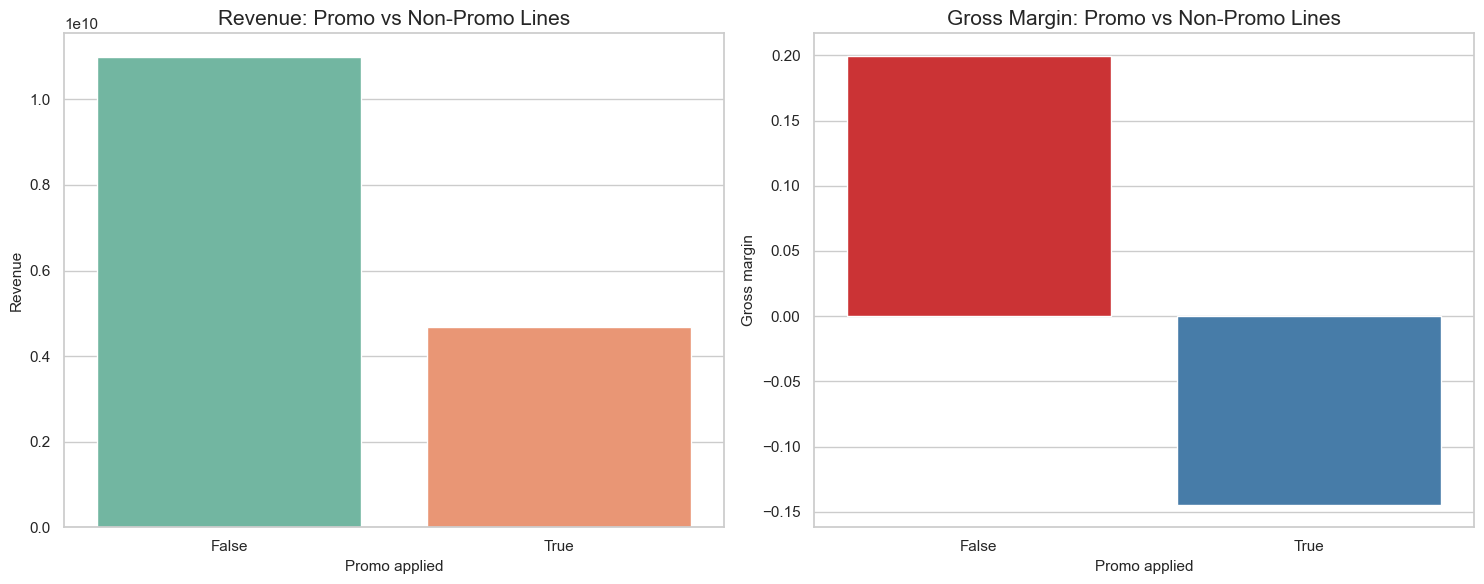

Saved figure: outputs\figures\fig9_promo_vs_nonpromo.png


,promo_applied,lines,revenue,gross_profit,avg_discount,return_rate,gross_margin
0,False,438353,1.099504e+10,2.195015e+09,0.00000,0.055898,0.199637
1,True,276316,4.685830e+09,-6.775966e+08,2712.86252,0.055864,-0.144605


In [14]:
# Chart 4A — Promo vs non-promo lines
promo_analysis = line_items.groupby("promo_applied", as_index=False).agg(
    lines=("order_id", "count"),
    revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    avg_discount=("discount_amount", "mean"),
    return_rate=("is_returned", "mean"),
)
promo_analysis["gross_margin"] = promo_analysis["gross_profit"] / promo_analysis["revenue"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=promo_analysis, x="promo_applied", y="revenue", ax=axes[0], palette="Set2")
axes[0].set_title("Revenue: Promo vs Non-Promo Lines")
axes[0].set_xlabel("Promo applied")
axes[0].set_ylabel("Revenue")

sns.barplot(data=promo_analysis, x="promo_applied", y="gross_margin", ax=axes[1], palette="Set1")
axes[1].set_title("Gross Margin: Promo vs Non-Promo Lines")
axes[1].set_xlabel("Promo applied")
axes[1].set_ylabel("Gross margin")

save_fig("fig9_promo_vs_nonpromo.png")
promo_analysis

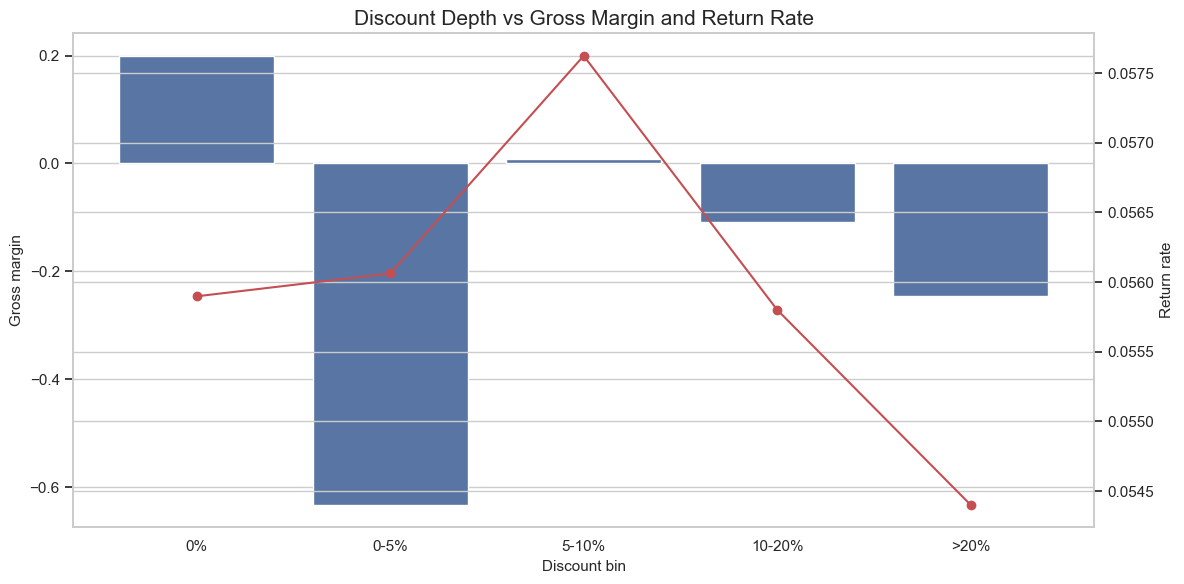

Saved figure: outputs\figures\fig10_discount_depth_margin_return.png


,discount_bin,lines,gross_margin,return_rate
0,0%,438353,0.199637,0.055898
1,0-5%,20852,-0.632791,0.056062
2,5-10%,26378,0.008735,0.057624
3,10-20%,203186,-0.108491,0.055801
4,>20%,25900,-0.245586,0.054402


In [15]:
# Chart 4B — Discount depth vs margin and return rate
x = line_items[line_items["gross_revenue"] > 0].copy()
x["discount_bin"] = pd.cut(
    x["discount_pct"],
    bins=[-0.001, 0, 0.05, 0.1, 0.2, 1],
    labels=["0%", "0-5%", "5-10%", "10-20%", ">20%"]
)

disc = x.groupby("discount_bin", as_index=False).agg(
    lines=("order_id", "count"),
    gross_margin=("gross_profit", lambda s: s.sum() / x.loc[s.index, "net_revenue"].sum() if x.loc[s.index, "net_revenue"].sum() else np.nan),
    return_rate=("is_returned", "mean"),
)

fig, ax1 = plt.subplots(figsize=(12, 6))
sns.barplot(data=disc, x="discount_bin", y="gross_margin", ax=ax1, color="#4C72B0")
ax1.set_title("Discount Depth vs Gross Margin and Return Rate")
ax1.set_xlabel("Discount bin")
ax1.set_ylabel("Gross margin")

ax2 = ax1.twinx()
ax2.plot(range(len(disc)), disc["return_rate"], color="#C44E52", marker="o")
ax2.set_ylabel("Return rate")

save_fig("fig10_discount_depth_margin_return.png")
disc

### Insight — Hiệu quả khuyến mãi và rủi ro bào mòn lợi nhuận

**Phát hiện chính:** Các dòng sản phẩm có khuyến mãi có thể đóng góp đáng kể vào doanh thu, nhưng không nên kết luận rằng khuyến mãi trực tiếp tạo ra tăng trưởng nếu chưa có phân tích nhân quả. Cách diễn giải đúng là: các dòng có khuyến mãi có liên hệ với sự thay đổi về doanh thu, số lượng bán và biên lợi nhuận. Vì vậy, hiệu quả khuyến mãi cần được đánh giá đồng thời trên cả revenue, discount depth, gross margin và return rate.

**Ý nghĩa kinh doanh:** Nếu doanh nghiệp chỉ nhìn doanh thu sau khuyến mãi, rất dễ đánh giá sai hiệu quả thật. Một chương trình giảm giá có thể làm đơn hàng tăng nhưng đồng thời bào mòn gross margin, tăng áp lực tồn kho và không làm giảm tỷ lệ trả hàng. Trong trường hợp đó, doanh nghiệp đang “mua doanh thu” bằng lợi nhuận, thay vì tạo tăng trưởng bền vững.

**Đề xuất hành động:** Không nên discount dàn trải trên toàn bộ danh mục. Doanh nghiệp nên thiết lập ngưỡng kiểm soát biên lợi nhuận cho từng chương trình khuyến mãi. Khuyến mãi nên tập trung vào các category có nhu cầu tốt, biên lợi nhuận còn đủ an toàn và tỷ lệ trả hàng được kiểm soát. Với nhóm return cao hoặc margin thấp, nên hạn chế giảm giá trực tiếp và cân nhắc các hình thức khác như bundle, voucher theo ngưỡng đơn hàng, loyalty points hoặc clearance có kiểm soát.

# 5. Returns & Customer Experience

**Câu hỏi kinh doanh:** Sản phẩm nào tạo rủi ro hoàn trả? Vấn đề nằm ở size, mô tả, chất lượng hay giao hàng?

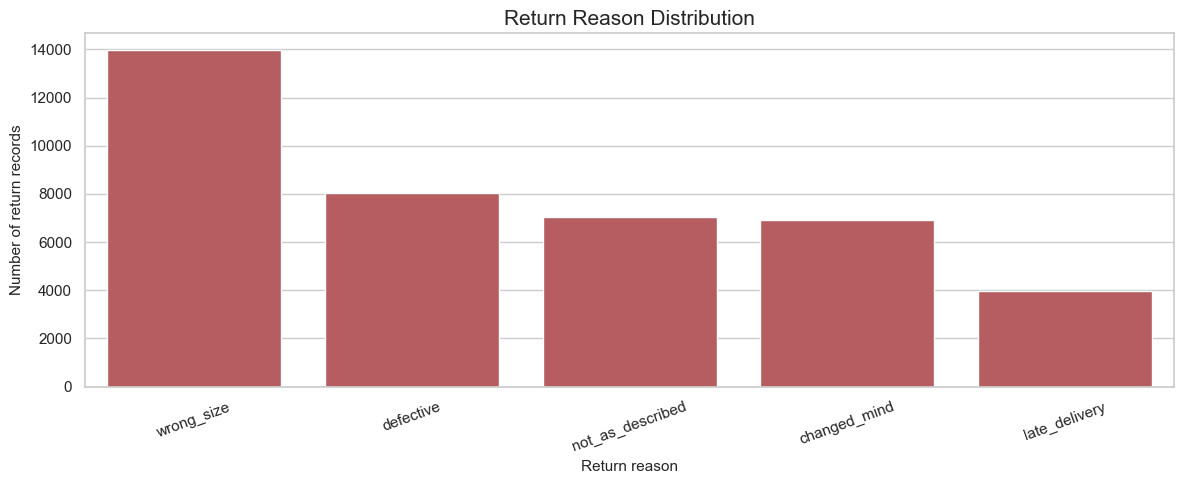

Saved figure: outputs\figures\fig11_return_reason_distribution.png


,return_reason,count,share
0,wrong_size,13967,0.349708
1,defective,8020,0.200806
2,not_as_described,7035,0.176144
3,changed_mind,6931,0.173540
4,late_delivery,3986,0.099802


In [16]:
# Chart 5A — Return reason distribution
reason = returns["return_reason"].value_counts().reset_index()
reason.columns = ["return_reason", "count"]
reason["share"] = reason["count"] / reason["count"].sum()

plt.figure(figsize=(12, 5))
sns.barplot(data=reason, x="return_reason", y="count", color="#C44E52")
plt.title("Return Reason Distribution")
plt.xlabel("Return reason")
plt.ylabel("Number of return records")
plt.xticks(rotation=20)
save_fig("fig11_return_reason_distribution.png")
reason

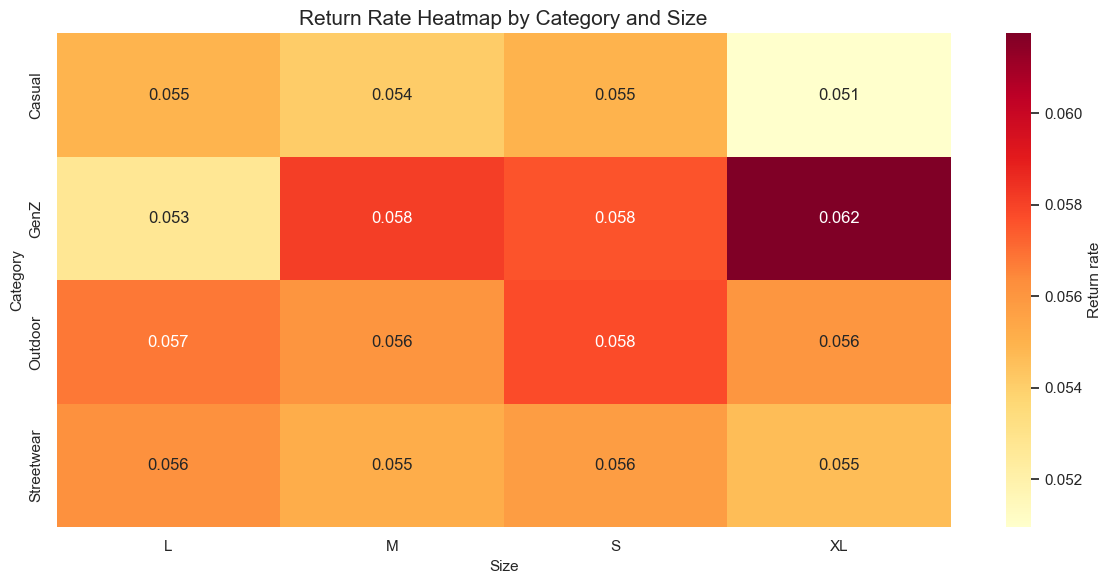

Saved figure: outputs\figures\fig12_return_rate_category_size_heatmap.png


,category,size,lines,return_rate
7,GenZ,XL,5393,0.061747
5,GenZ,M,10275,0.058102
10,Outdoor,S,55596,0.057756
6,GenZ,S,12899,0.057601
8,Outdoor,L,72086,0.056779
12,Streetwear,L,88765,0.056216
9,Outdoor,M,70915,0.056067
11,Outdoor,XL,61389,0.056036
14,Streetwear,S,95328,0.055776
13,Streetwear,M,87809,0.055177


In [17]:
# Chart 5B — Return rate heatmap by category and size
size_cat = line_items.groupby(["category", "size"], as_index=False).agg(
    lines=("order_id", "count"),
    return_rate=("is_returned", "mean")
)
heat_size = size_cat.pivot(index="category", columns="size", values="return_rate")

plt.figure(figsize=(12, 6))
sns.heatmap(heat_size, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={"label": "Return rate"})
plt.title("Return Rate Heatmap by Category and Size")
plt.xlabel("Size")
plt.ylabel("Category")
save_fig("fig12_return_rate_category_size_heatmap.png")
size_cat.sort_values("return_rate", ascending=False).head(12)

### Insight — Trả hàng và trải nghiệm sau mua

**Phát hiện chính:** Các lý do trả hàng phản ánh trực tiếp điểm yếu trong trải nghiệm khách hàng sau mua. Nếu `wrong_size` là lý do nổi bật, vấn đề chính nằm ở khả năng khách hàng chọn đúng kích cỡ và kỳ vọng về form dáng sản phẩm. Nếu `defective` cao, rủi ro nằm ở chất lượng sản phẩm hoặc nhà cung cấp. Nếu `not_as_described` cao, vấn đề nằm ở khoảng cách giữa thông tin sản phẩm trên website và trải nghiệm thực tế khi nhận hàng.

**Ý nghĩa kinh doanh:** Trả hàng không chỉ làm giảm doanh thu thuần mà còn tạo thêm chi phí logistics ngược, hoàn tiền, xử lý kho và giảm mức độ hài lòng của khách hàng. Nếu không xử lý nguyên nhân gốc, doanh nghiệp có thể tiếp tục tăng doanh thu ban đầu nhưng lợi nhuận sau cùng bị suy giảm do chi phí hoàn trả và trải nghiệm khách hàng kém.

**Đề xuất hành động:** Với nhóm trả hàng do `wrong_size`, doanh nghiệp nên cải thiện size guide, ảnh người mẫu mặc thực tế, thông tin chiều cao/cân nặng mẫu và tư vấn chọn size. Với nhóm `defective`, cần tăng kiểm soát chất lượng nhà cung cấp và quy trình kiểm hàng trước khi giao. Với nhóm `not_as_described`, cần cải thiện ảnh sản phẩm, mô tả chất liệu, form dáng, màu sắc và hiển thị review thực tế để giảm khoảng cách kỳ vọng của khách hàng.

# 6. Inventory & Operations

**Câu hỏi kinh doanh:** Doanh nghiệp đang thiếu hàng ở đâu, dư hàng ở đâu, và có rủi ro mất doanh thu do stockout không?

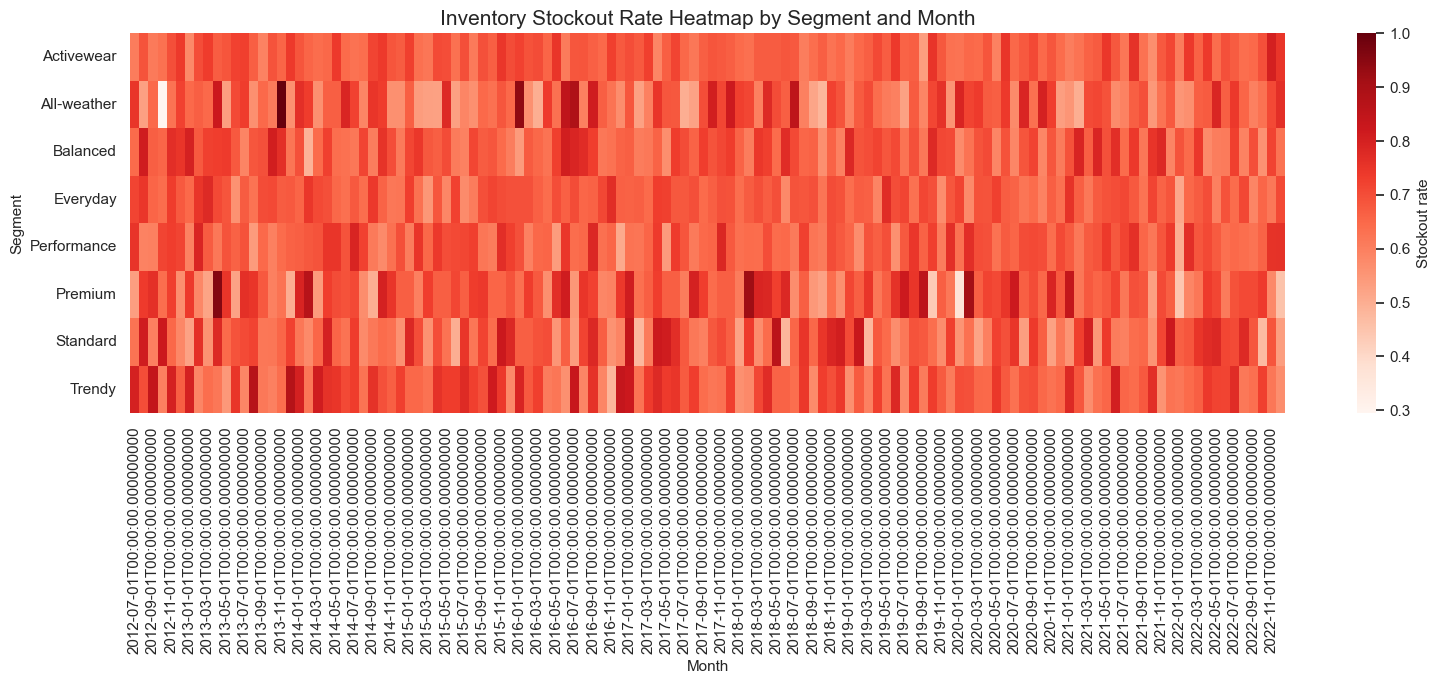

Saved figure: outputs\figures\fig13_inventory_stockout_heatmap.png


In [18]:
# Chart 6A — Stockout heatmap by segment and month
inventory["month"] = inventory["snapshot_date"].dt.to_period("M").dt.to_timestamp()
inv_seg = inventory.groupby(["month", "segment"], as_index=False).agg(
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    avg_fill_rate=("fill_rate", "mean"),
    avg_sell_through=("sell_through_rate", "mean"),
    avg_days_of_supply=("days_of_supply", "mean"),
)

pivot_stockout = inv_seg.pivot(index="segment", columns="month", values="stockout_rate")

plt.figure(figsize=(16, 7))
sns.heatmap(pivot_stockout, cmap="Reds", cbar_kws={"label": "Stockout rate"})
plt.title("Inventory Stockout Rate Heatmap by Segment and Month")
plt.xlabel("Month")
plt.ylabel("Segment")
save_fig("fig13_inventory_stockout_heatmap.png")

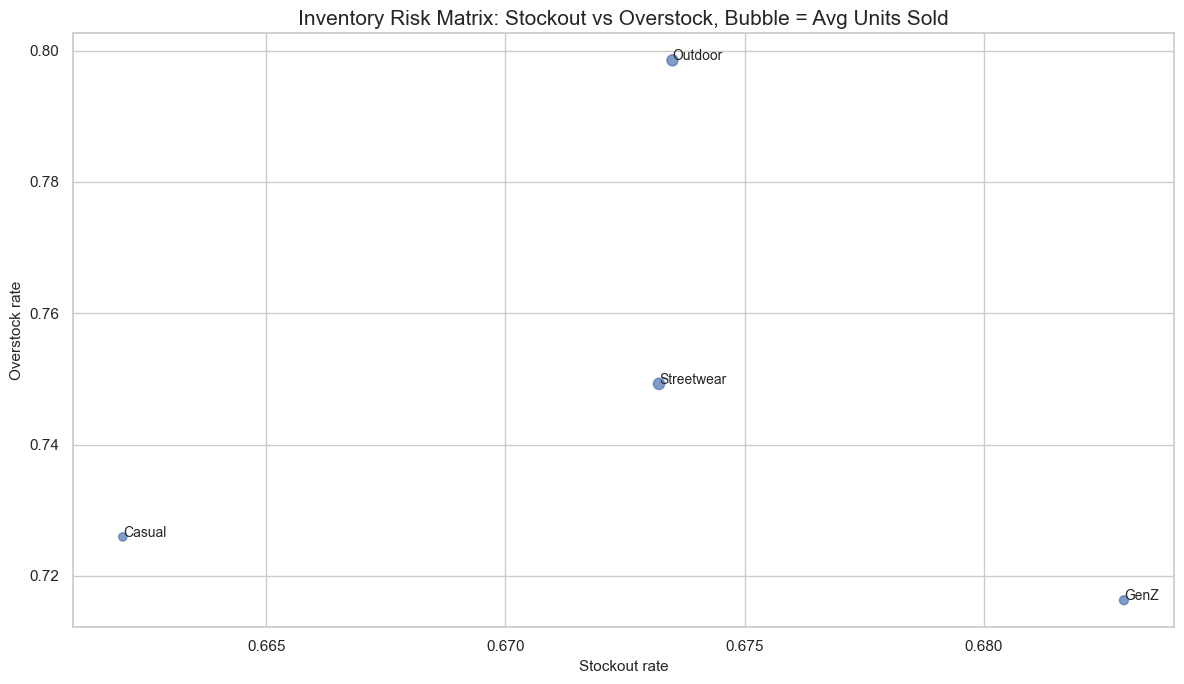

Saved figure: outputs\figures\fig14_inventory_risk_matrix.png


,category,stockout_rate,overstock_rate,avg_sell_through,avg_days_supply,avg_units_sold
1,GenZ,0.682927,0.716303,0.167978,718.812174,10.418271
2,Outdoor,0.673492,0.798527,0.135084,1068.837815,16.033729
3,Streetwear,0.673211,0.749259,0.159754,887.136692,16.488298
0,Casual,0.662004,0.725949,0.168390,459.132629,8.907222


In [19]:
# Chart 6B — Inventory risk matrix by category
inv_cat = inventory.groupby("category", as_index=False).agg(
    stockout_rate=("stockout_flag", "mean"),
    overstock_rate=("overstock_flag", "mean"),
    avg_sell_through=("sell_through_rate", "mean"),
    avg_days_supply=("days_of_supply", "mean"),
    avg_units_sold=("units_sold", "mean")
)

plt.figure(figsize=(12, 7))
plt.scatter(inv_cat["stockout_rate"], inv_cat["overstock_rate"], s=inv_cat["avg_units_sold"]*4, alpha=0.7)
for _, r in inv_cat.iterrows():
    plt.annotate(r["category"], (r["stockout_rate"], r["overstock_rate"]), fontsize=10)
plt.title("Inventory Risk Matrix: Stockout vs Overstock, Bubble = Avg Units Sold")
plt.xlabel("Stockout rate")
plt.ylabel("Overstock rate")
save_fig("fig14_inventory_risk_matrix.png")
inv_cat.sort_values("stockout_rate", ascending=False)

### Insight — Tồn kho và quyết định vận hành

**Phát hiện chính:** Các nhóm sản phẩm có stockout cao và sell-through cao cho thấy doanh nghiệp có thể đang mất cơ hội bán hàng vì không đủ hàng đúng lúc. Ngược lại, các nhóm có overstock cao và sell-through thấp cho thấy vốn đang bị chôn trong các sản phẩm bán chậm. Hai vấn đề này có thể cùng tồn tại nếu tồn kho được phân bổ sai giữa các SKU.

**Ý nghĩa kinh doanh:** Stockout làm mất doanh thu trong giai đoạn có nhu cầu thật, trong khi overstock làm tăng chi phí lưu kho, gây áp lực giảm giá và làm giảm hiệu quả sử dụng vốn. Vì vậy, vấn đề không chỉ là “tăng hay giảm tồn kho”, mà là phân bổ tồn kho đúng sản phẩm, đúng thời điểm và đúng mức nhu cầu.

**Đề xuất hành động:** Với nhóm stockout cao và sell-through cao, doanh nghiệp nên tái đặt hàng sớm hơn, tăng tồn kho an toàn và ưu tiên phân bổ cho các khu vực/kênh có nhu cầu cao. Với nhóm overstock cao và sell-through thấp, cần giảm kế hoạch nhập hàng kỳ sau, chạy clearance campaign có kiểm soát hoặc bundle để giải phóng tồn kho. Đây là một trong những insight Prescriptive rõ nhất vì trực tiếp chuyển hóa dữ liệu thành quyết định tồn kho và mua hàng.

# 7. Web Traffic & Marketing Efficiency

**Câu hỏi kinh doanh:** Traffic có chuyển thành đơn hàng không? Nguồn nào chất lượng hơn?

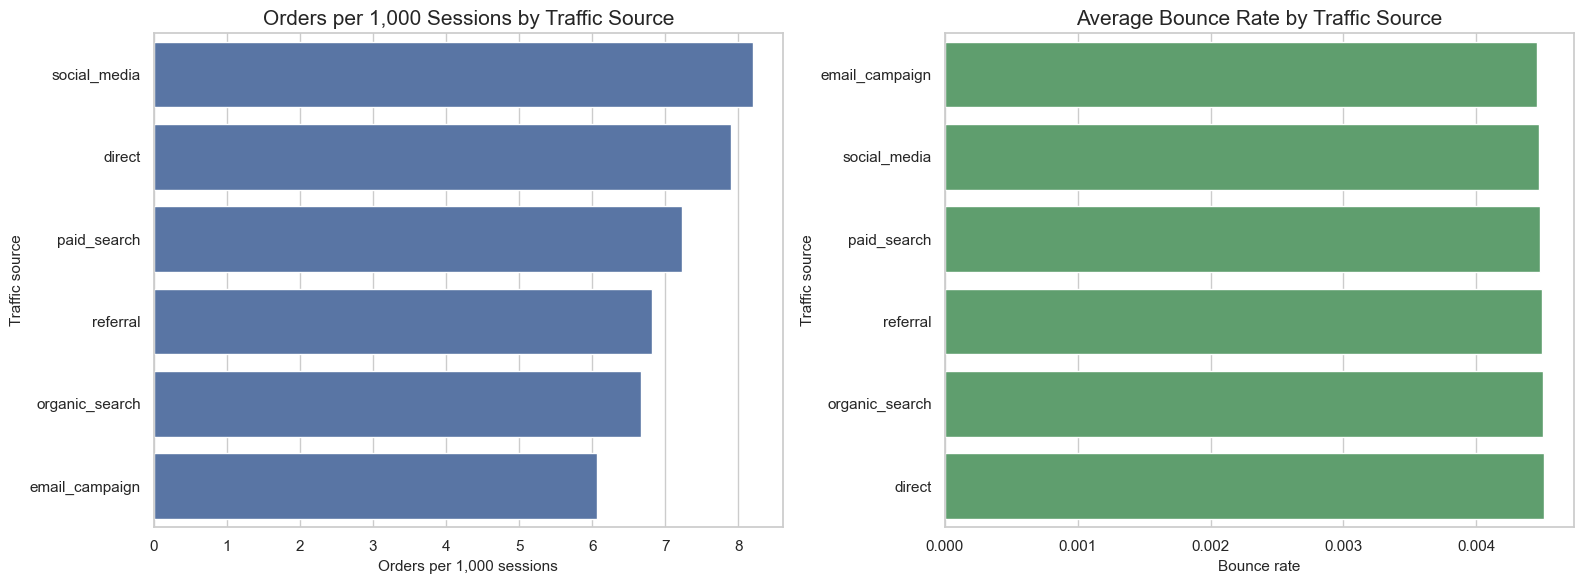

Saved figure: outputs\figures\fig15_traffic_source_efficiency.png


,traffic_source,sessions,avg_bounce_rate,avg_session_duration,order_source,orders,orders_per_1k_sessions
5,social_media,15816226,0.004476,210.290190,social_media,129710,8.201071
0,direct,6571549,0.004511,207.678195,direct,51951,7.905442
3,paid_search,19598271,0.004478,209.362117,paid_search,141652,7.227780
4,referral,9476845,0.004499,207.558667,referral,64565,6.812921
2,organic_search,27196976,0.004504,211.153945,organic_search,181495,6.673352
1,email_campaign,12792670,0.004458,213.220594,email_campaign,77572,6.063785


In [20]:
# Chart 7A — Orders per 1,000 sessions by traffic source
traffic_src = web_traffic.groupby("traffic_source", as_index=False).agg(
    sessions=("sessions", "sum"),
    avg_bounce_rate=("bounce_rate", "mean"),
    avg_session_duration=("avg_session_duration_sec", "mean"),
)
orders_src = orders.groupby("order_source", as_index=False).agg(orders=("order_id", "nunique"))

efficiency = traffic_src.merge(orders_src, left_on="traffic_source", right_on="order_source", how="left")
efficiency["orders"] = efficiency["orders"].fillna(0)
efficiency["orders_per_1k_sessions"] = efficiency["orders"] / efficiency["sessions"] * 1000

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=efficiency.sort_values("orders_per_1k_sessions", ascending=False),
            x="orders_per_1k_sessions", y="traffic_source", ax=axes[0], color="#4C72B0")
axes[0].set_title("Orders per 1,000 Sessions by Traffic Source")
axes[0].set_xlabel("Orders per 1,000 sessions")
axes[0].set_ylabel("Traffic source")

sns.barplot(data=efficiency.sort_values("avg_bounce_rate"),
            x="avg_bounce_rate", y="traffic_source", ax=axes[1], color="#55A868")
axes[1].set_title("Average Bounce Rate by Traffic Source")
axes[1].set_xlabel("Bounce rate")
axes[1].set_ylabel("Traffic source")

save_fig("fig15_traffic_source_efficiency.png")
efficiency.sort_values("orders_per_1k_sessions", ascending=False)

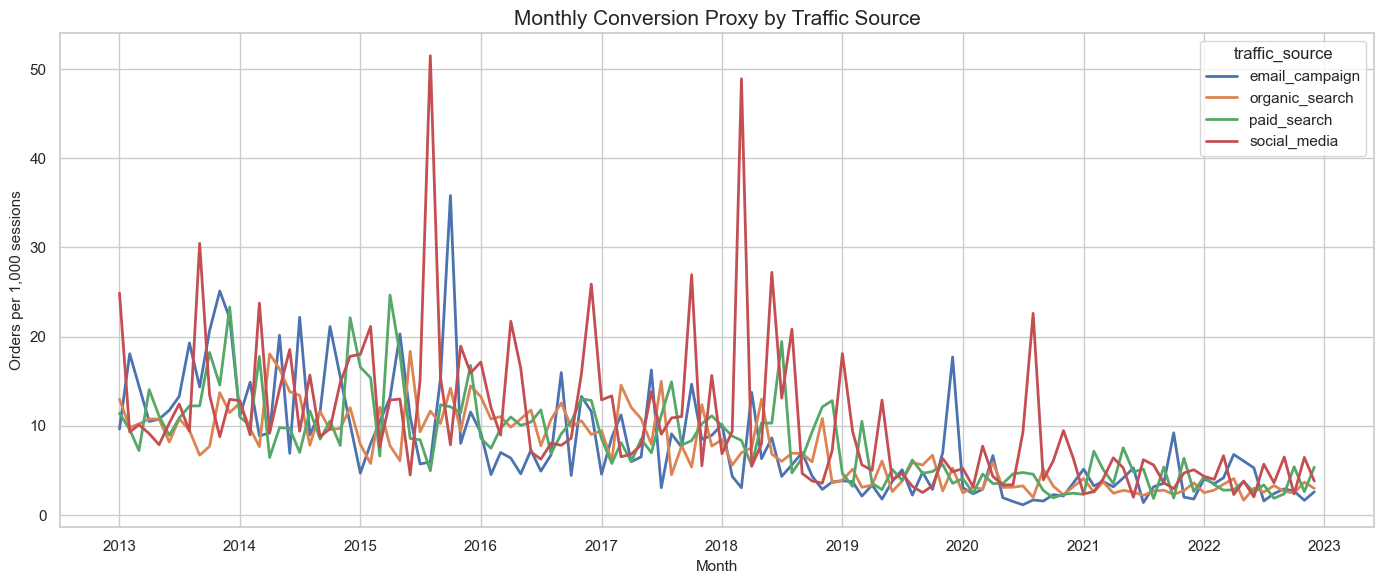

Saved figure: outputs\figures\fig16_monthly_conversion_proxy.png


,traffic_source,orders_per_1k_sessions
3,social_media,10.402056
2,paid_search,8.210186
0,email_campaign,7.908373
1,organic_search,7.393663


In [21]:
# Chart 7B — Monthly conversion proxy by traffic source
traffic_m = web_traffic.copy()
traffic_m["month"] = traffic_m["date"].dt.to_period("M").dt.to_timestamp()
traffic_m = traffic_m.groupby(["month", "traffic_source"], as_index=False).agg(sessions=("sessions", "sum"))

orders_m = orders.copy()
orders_m["month"] = orders_m["order_date"].dt.to_period("M").dt.to_timestamp()
orders_m = orders_m.groupby(["month", "order_source"], as_index=False).agg(orders=("order_id", "nunique")).rename(columns={"order_source": "traffic_source"})

conv = traffic_m.merge(orders_m, on=["month", "traffic_source"], how="left")
conv["orders"] = conv["orders"].fillna(0)
conv["orders_per_1k_sessions"] = conv["orders"] / conv["sessions"] * 1000

top_src = conv.groupby("traffic_source")["orders"].sum().sort_values(ascending=False).head(4).index
conv_top = conv[conv["traffic_source"].isin(top_src)]

plt.figure(figsize=(14, 6))
sns.lineplot(data=conv_top, x="month", y="orders_per_1k_sessions", hue="traffic_source", linewidth=2)
plt.title("Monthly Conversion Proxy by Traffic Source")
plt.xlabel("Month")
plt.ylabel("Orders per 1,000 sessions")
save_fig("fig16_monthly_conversion_proxy.png")
conv_top.groupby("traffic_source", as_index=False)["orders_per_1k_sessions"].mean().sort_values("orders_per_1k_sessions", ascending=False)

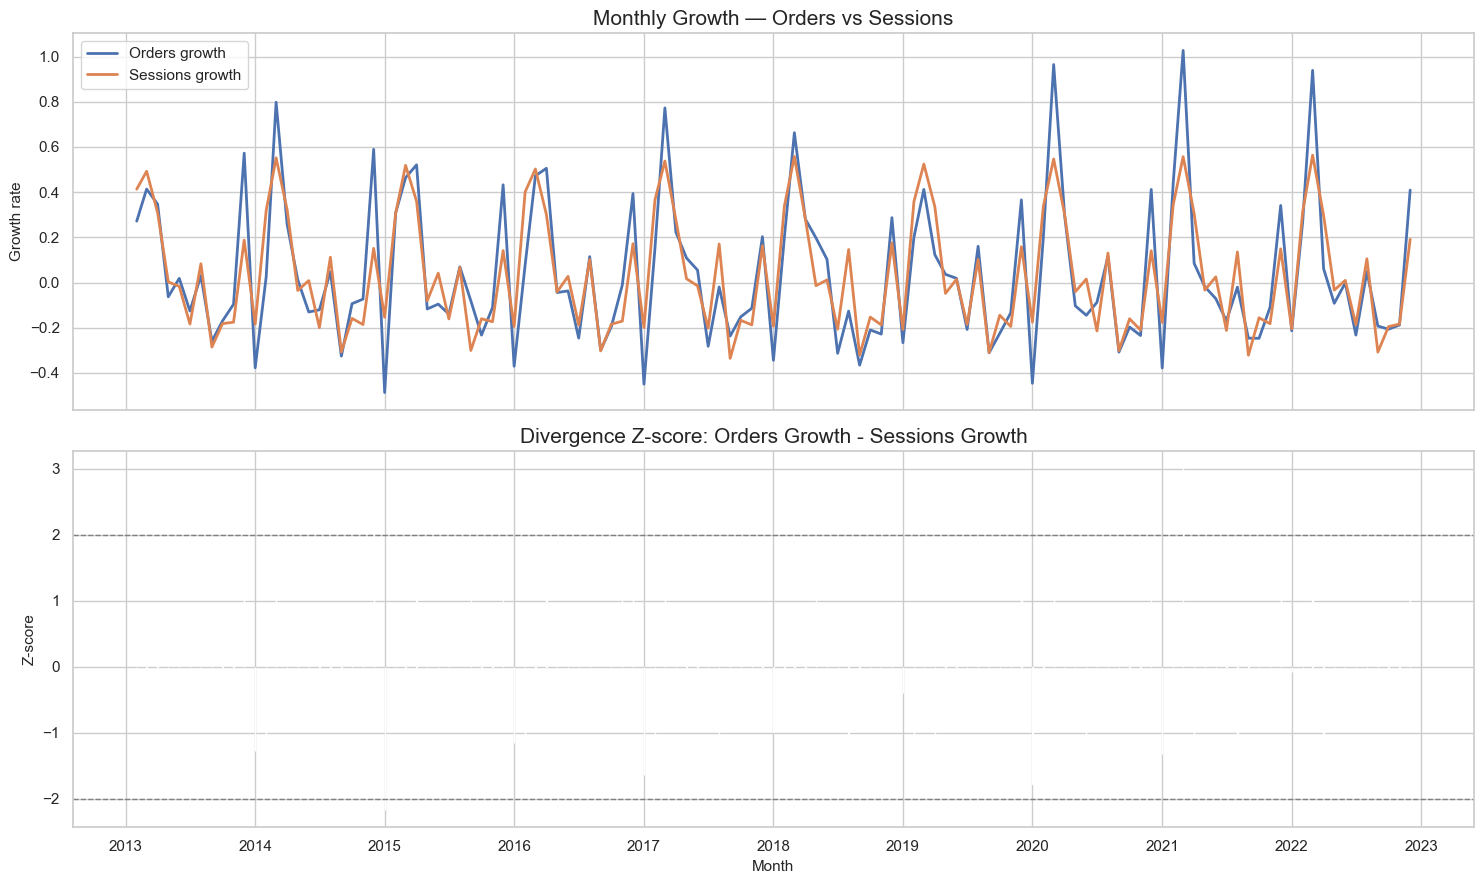

Saved figure: outputs\figures\fig17_traffic_orders_divergence.png


,month,orders_growth,sessions_growth,gap_growth,gap_zscore
98,2021-03-01,1.027328,0.557119,0.470208,3.014067
23,2014-12-01,0.589459,0.151392,0.438068,2.806487
86,2020-03-01,0.964865,0.546823,0.418042,2.677151
11,2013-12-01,0.572541,0.187754,0.384787,2.462378
110,2022-03-01,0.939047,0.563779,0.375268,2.400897
37,2016-02-01,0.077928,0.401033,-0.323105,-2.109505
24,2015-01-01,-0.486836,-0.153866,-0.332971,-2.173222


In [22]:
# Chart 7C — Traffic vs orders divergence as predictive warning signal

# Ensure datetime format
orders["order_date"] = pd.to_datetime(orders["order_date"])
web_traffic["date"] = pd.to_datetime(web_traffic["date"])

# Create month column explicitly
orders_tmp = orders.copy()
traffic_tmp = web_traffic.copy()

orders_tmp["month"] = orders_tmp["order_date"].dt.to_period("M").dt.to_timestamp()
traffic_tmp["month"] = traffic_tmp["date"].dt.to_period("M").dt.to_timestamp()

# Aggregate orders and sessions by month
orders_month = (
    orders_tmp.groupby("month", as_index=False)
    .agg(orders=("order_id", "nunique"))
)

traffic_month = (
    traffic_tmp.groupby("month", as_index=False)
    .agg(sessions=("sessions", "sum"))
)

# Merge monthly orders and traffic
anom = (
    orders_month
    .merge(traffic_month, on="month", how="inner")
    .sort_values("month")
)

# Calculate growth rates
anom["orders_growth"] = anom["orders"].pct_change()
anom["sessions_growth"] = anom["sessions"].pct_change()

# Difference between order growth and traffic growth
anom["gap_growth"] = anom["orders_growth"] - anom["sessions_growth"]

# Avoid NaN / infinite issues
anom = anom.replace([np.inf, -np.inf], np.nan)

# Z-score of divergence
gap_mean = anom["gap_growth"].mean()
gap_std = anom["gap_growth"].std(ddof=0)

anom["gap_zscore"] = (anom["gap_growth"] - gap_mean) / gap_std

# Plot
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True)

axes[0].plot(anom["month"], anom["orders_growth"], label="Orders growth", linewidth=2)
axes[0].plot(anom["month"], anom["sessions_growth"], label="Sessions growth", linewidth=2)
axes[0].set_title("Monthly Growth — Orders vs Sessions")
axes[0].set_ylabel("Growth rate")
axes[0].legend()

axes[1].bar(
    anom["month"],
    anom["gap_zscore"]
)

axes[1].axhline(2, color="gray", linestyle="--", linewidth=1)
axes[1].axhline(-2, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Divergence Z-score: Orders Growth - Sessions Growth")
axes[1].set_ylabel("Z-score")
axes[1].set_xlabel("Month")

save_fig("fig17_traffic_orders_divergence.png")

# Show strongest divergence months
anom.loc[
    anom["gap_zscore"].abs() >= 2,
    ["month", "orders_growth", "sessions_growth", "gap_growth", "gap_zscore"]
].sort_values("gap_zscore", ascending=False).head(10)

### Insight — Hiệu quả traffic và chất lượng chuyển đổi

**Phát hiện chính:** Traffic cao chưa chắc phản ánh hiệu quả kinh doanh tốt. Một nguồn truy cập có thể tạo nhiều sessions nhưng không tạo ra lượng orders tương ứng. Vì vậy, cần đánh giá marketing channel bằng conversion proxy, orders per session, bounce rate và xu hướng tăng trưởng đơn hàng, thay vì chỉ nhìn tổng traffic.

**Ý nghĩa kinh doanh:** Khi sessions tăng nhưng orders không tăng tương ứng, nút thắt có thể nằm ở chất lượng traffic hoặc trải nghiệm chuyển đổi. Các nguyên nhân có thể bao gồm landing page chưa phù hợp, sản phẩm không khớp nhu cầu người dùng, ưu đãi chưa đủ hấp dẫn, trải nghiệm checkout có ma sát hoặc thông điệp marketing không nhất quán với sản phẩm thực tế.

**Đề xuất hành động:** Doanh nghiệp nên phân bổ ngân sách marketing dựa trên chất lượng chuyển đổi, không chỉ dựa trên số phiên truy cập. Các kênh có conversion proxy tốt và bounce rate thấp nên được ưu tiên mở rộng. Với các kênh có traffic cao nhưng conversion thấp, cần tối ưu landing page, thông điệp quảng cáo, đề xuất sản phẩm, ưu đãi và quy trình checkout trước khi tiếp tục tăng ngân sách.

# 8. Prescriptive Action Playbook

Phần này dùng các kết quả ở trên để biến insight thành hành động. Đây là phần giúp dashboard đạt cấp độ **Prescriptive** trong rubric.

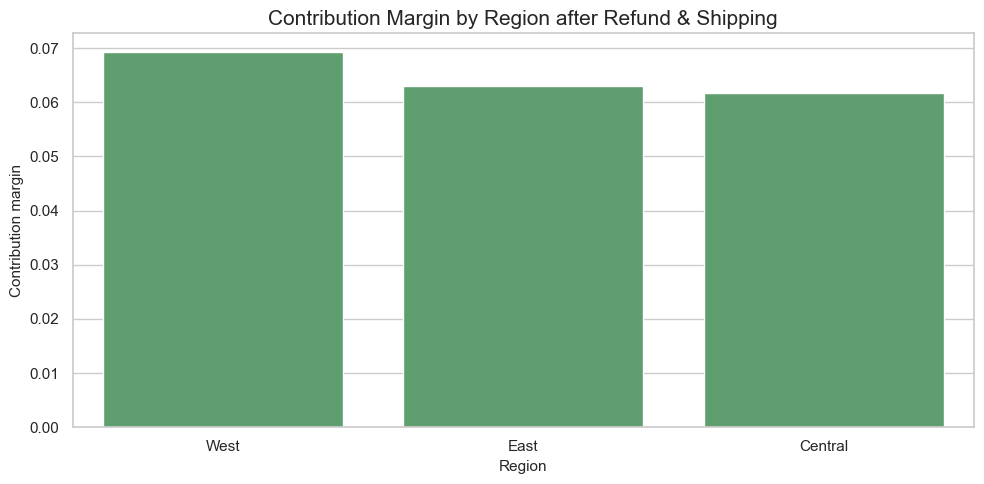

Saved figure: outputs\figures\fig18_region_contribution_margin.png


,region,orders,net_revenue,gross_profit,refund,shipping_fee,contribution_profit,contribution_margin
2,West,167642,3.670227e+09,3.787095e+08,1.237297e+08,791855.41,2.541880e+08,0.069257
1,East,294612,7.291151e+09,6.956483e+08,2.354817e+08,1244288.28,4.589223e+08,0.062942
0,Central,184691,4.719491e+09,4.430609e+08,1.513871e+08,773165.97,2.909007e+08,0.061638


In [23]:
# Chart 8A — Contribution margin by region after refund and shipping
order_fin = line_items.groupby("order_id", as_index=False).agg(
    net_revenue=("net_revenue", "sum"),
    line_cogs=("line_cogs", "sum"),
    gross_profit=("gross_profit", "sum"),
)
refund_order = returns.groupby("order_id", as_index=False).agg(refund_amount=("refund_amount", "sum"))
ship_fee_order = shipments.groupby("order_id", as_index=False).agg(shipping_fee=("shipping_fee", "sum"))
order_region = orders.merge(geography[["zip", "region"]].drop_duplicates("zip"), on="zip", how="left")[["order_id", "region"]]

unit = order_fin.merge(refund_order, on="order_id", how="left").merge(ship_fee_order, on="order_id", how="left").merge(order_region, on="order_id", how="left")
unit[["refund_amount", "shipping_fee"]] = unit[["refund_amount", "shipping_fee"]].fillna(0)
unit["contribution_profit"] = unit["gross_profit"] - unit["refund_amount"] - unit["shipping_fee"]
unit["contribution_margin"] = unit["contribution_profit"] / unit["net_revenue"].replace(0, np.nan)

region_unit = unit.groupby("region", as_index=False).agg(
    orders=("order_id", "nunique"),
    net_revenue=("net_revenue", "sum"),
    gross_profit=("gross_profit", "sum"),
    refund=("refund_amount", "sum"),
    shipping_fee=("shipping_fee", "sum"),
    contribution_profit=("contribution_profit", "sum"),
)
region_unit["contribution_margin"] = region_unit["contribution_profit"] / region_unit["net_revenue"]

plt.figure(figsize=(10, 5))
sns.barplot(data=region_unit.sort_values("contribution_margin", ascending=False), x="region", y="contribution_margin", color="#55A868")
plt.title("Contribution Margin by Region after Refund & Shipping")
plt.xlabel("Region")
plt.ylabel("Contribution margin")
save_fig("fig18_region_contribution_margin.png")
region_unit.sort_values("contribution_margin", ascending=False)

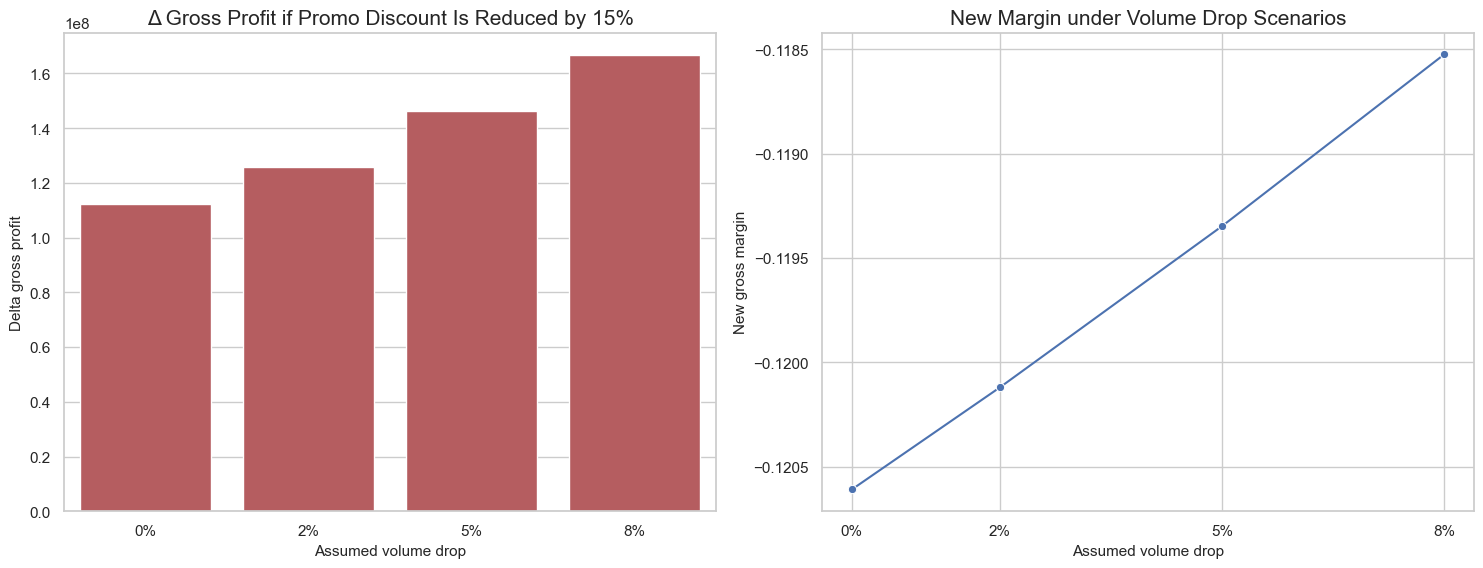

Saved figure: outputs\figures\fig19_promo_discount_simulator.png


,volume_drop_pct,new_revenue,new_gross_profit,delta_gross_profit,new_margin
0,0.00,4.685830e+09,-5.651555e+08,1.124411e+08,-0.120609
1,0.02,4.592114e+09,-5.516036e+08,1.259930e+08,-0.120120
2,0.05,4.451539e+09,-5.312757e+08,1.463209e+08,-0.119347
3,0.08,4.310964e+09,-5.109478e+08,1.666488e+08,-0.118523


In [24]:
# Chart 8B — Prescriptive simulator: reduce promo discount by 15%
promo_lines = line_items[line_items["promo_applied"]].copy()
base_rev = promo_lines["net_revenue"].sum()
base_gp = promo_lines["gross_profit"].sum()
base_disc = promo_lines["discount_amount"].fillna(0).sum()

scenarios = []
for volume_drop in [0.00, 0.02, 0.05, 0.08]:
    new_discount = base_disc * 0.85
    recovered_discount = base_disc - new_discount
    new_revenue = base_rev * (1 - volume_drop)
    gp_lost_from_volume = base_gp * volume_drop
    new_gp = base_gp + recovered_discount - gp_lost_from_volume
    scenarios.append({
        "volume_drop_pct": volume_drop,
        "new_revenue": new_revenue,
        "new_gross_profit": new_gp,
        "delta_gross_profit": new_gp - base_gp,
        "new_margin": new_gp / new_revenue if new_revenue else np.nan,
    })

sim = pd.DataFrame(scenarios)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(data=sim, x="volume_drop_pct", y="delta_gross_profit", ax=axes[0], color="#C44E52")
axes[0].set_title("Δ Gross Profit if Promo Discount Is Reduced by 15%")
axes[0].set_xlabel("Assumed volume drop")
axes[0].set_ylabel("Delta gross profit")
axes[0].set_xticklabels([f"{v:.0%}" for v in sim["volume_drop_pct"]])

sns.lineplot(data=sim, x="volume_drop_pct", y="new_margin", marker="o", ax=axes[1], color="#4C72B0")
axes[1].set_title("New Margin under Volume Drop Scenarios")
axes[1].set_xlabel("Assumed volume drop")
axes[1].set_ylabel("New gross margin")
axes[1].set_xticks(sim["volume_drop_pct"])
axes[1].set_xticklabels([f"{v:.0%}" for v in sim["volume_drop_pct"]])

save_fig("fig19_promo_discount_simulator.png")
sim

In [25]:
# Final action playbook table
best_source = efficiency.sort_values("orders_per_1k_sessions", ascending=False).iloc[0]["traffic_source"]
top_return_reason = returns["return_reason"].value_counts().index[0]
worst_stockout_category = inv_cat.sort_values("stockout_rate", ascending=False).iloc[0]["category"]
worst_overstock_category = inv_cat.sort_values("overstock_rate", ascending=False).iloc[0]["category"]

playbook = pd.DataFrame([
    {
        "Priority": 1,
        "Focus": "Retention and customer quality",
        "Action": "Run CRM/win-back campaigns for cohorts/channels with low repeat rate.",
        "KPI": "Repeat rate, revenue from returning customers, orders/customer",
    },
    {
        "Priority": 2,
        "Focus": "Promotion efficiency",
        "Action": "Reduce blanket discounts; prioritize discount only where margin remains healthy.",
        "KPI": "Gross margin, discount rate, promo revenue, return rate",
    },
    {
        "Priority": 3,
        "Focus": "Return reduction",
        "Action": f"Address dominant return reason: {top_return_reason}; improve size guide/product description/QC depending on reason.",
        "KPI": "Return rate, refund amount, rating",
    },
    {
        "Priority": 4,
        "Focus": "Inventory allocation",
        "Action": f"Increase reorder discipline for high-stockout category: {worst_stockout_category}; clear overstock in {worst_overstock_category}.",
        "KPI": "Stockout rate, overstock rate, sell-through, days of supply",
    },
    {
        "Priority": 5,
        "Focus": "Marketing channel quality",
        "Action": f"Scale high-efficiency source ({best_source}); fix landing/checkout for sources with weak conversion proxy.",
        "KPI": "Orders/1k sessions, bounce rate, conversion proxy",
    },
])
playbook

,Priority,Focus,Action,KPI
0,1,Retention and customer quality,Run CRM/win-back campaigns for cohorts/channel...,"Repeat rate, revenue from returning customers,..."
1,2,Promotion efficiency,Reduce blanket discounts; prioritize discount ...,"Gross margin, discount rate, promo revenue, re..."
2,3,Return reduction,Address dominant return reason: wrong_size; im...,"Return rate, refund amount, rating"
3,4,Inventory allocation,Increase reorder discipline for high-stockout ...,"Stockout rate, overstock rate, sell-through, d..."
4,5,Marketing channel quality,Scale high-efficiency source (social_media); f...,"Orders/1k sessions, bounce rate, conversion proxy"


# Final Dashboard-to-Report Selection

Để đưa vào báo cáo 4 trang, không dùng toàn bộ chart. Chọn 5–6 chart mạnh nhất:

1. `fig1_revenue_profit_trend.png` — Revenue/profit overview.
2. `fig2_revenue_seasonality_month_heatmap.png` — Seasonality, phục vụ Predictive.
3. `fig5_new_vs_returning_revenue_mix.png` hoặc `fig4_repeat_rate_cohort_heatmap.png` — Customer retention.
4. `fig7_segment_portfolio_map.png` hoặc `fig8_category_revenue_share_over_time.png` — Product portfolio.
5. `fig10_discount_depth_margin_return.png` hoặc `fig9_promo_vs_nonpromo.png` — Promotion effectiveness.
6. `fig14_inventory_risk_matrix.png` hoặc `fig13_inventory_stockout_heatmap.png` — Inventory action.
7. `fig17_traffic_orders_divergence.png` nếu muốn nhấn mạnh predictive warning signal.

**Logic report nên viết:**  
Doanh nghiệp cần tăng trưởng nhưng không chỉ nhìn revenue. Các vấn đề nằm ở retention, promotion margin, return risk, inventory allocation và traffic conversion. Dashboard này đi từ mô tả → chẩn đoán → cảnh báo xu hướng → đề xuất hành động.